# Phase 1 : MLP Baseline - MNIST Classification
**Objectif** : Accuracy >95% sur test set

---

## Workflow 

1. **Setup** : Imports et configuration
2. **Data Loading** : Chargement et preprocessing
3. **Model Architecture** : Definition du modele
4. **Training** : Entrainement avec callbacks
5. **Evaluation** : Metriques sur test set
6. **Model Persistence** : Sauvegarde

---

## 1. Setup

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reproductibilite
np.random.seed(42)
keras.utils.set_random_seed(42)


2026-01-15 22:55:58.285640: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-15 22:55:58.530731: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-15 22:56:03.452461: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Setup complete


## 2. Data Loading & Preprocessing

In [2]:
# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocessing
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Train/validation split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train_cat, test_size=0.15, stratify=y_train, random_state=42
)

print(f'Training set: {X_train_final.shape[0]:,} samples')
print(f'Validation set: {X_val.shape[0]:,} samples')
print(f'Test set: {X_test.shape[0]:,} samples')

Training set: 51,000 samples
Validation set: 9,000 samples
Test set: 10,000 samples


## 3. Model Architecture

In [3]:
# Define model
model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

2026-01-15 22:56:07.552475: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

## 4. Training

In [4]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_mlp.h5', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

# Train
history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


2026-01-15 22:56:10.735384: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 159936000 exceeds 10% of free system memory.


399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8216 - loss: 0.5773

2026-01-15 22:56:29.423486: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 28224000 exceeds 10% of free system memory.


399/399 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.8991 - loss: 0.3268 - val_accuracy: 0.9544 - val_loss: 0.1470 - learning_rate: 0.0010
Epoch 2/30
398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9466 - loss: 0.1680

...

399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9890 - loss: 0.0350 - val_accuracy: 0.9820 - val_loss: 0.0724 - learning_rate: 5.0000e-04
Epoch 11/30
398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9902 - loss: 0.0293

399/399 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.9907 - loss: 0.0280 - val_accuracy: 0.9831 - val_loss: 0.0719 - learning_rate: 5.0000e-04
Epoch 12/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9920 - loss: 0.0247 - val_accuracy: 0.9831 - val_loss: 0.0765 - learning_rate: 5.0000e-04
Epoch 13/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9924 - loss: 0.0241 - val_accuracy: 0.9827 - val_loss: 0.0744 - learning_rate: 5.0000e-04
Epoch 14/30
397/399 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9920 - loss: 0.0244

399/399 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9926 - loss: 0.0228 - val_accuracy: 0.9837 - val_loss: 0.0757 - learning_rate: 5.0000e-04
Epoch 15/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9929 - loss: 0.0205

399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9940 - loss: 0.0182 - val_accuracy: 0.9844 - val_loss: 0.0706 - learning_rate: 2.5000e-04
Epoch 16/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9961 - loss: 0.0128 - val_accuracy: 0.9844 - val_loss: 0.0749 - learning_rate: 2.5000e-04
Epoch 17/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9961 - loss: 0.0121 - val_accuracy: 0.9843 - val_loss: 0.0740 - learning_rate: 2.5000e-04
Epoch 18/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9958 - loss: 0.0126 - val_accuracy: 0.9836 - val_loss: 0.0753 - learning_rate: 2.5000e-04
Epoch 19/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9969 - loss: 0.0100

399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9971 - loss: 0.0095 - val_accuracy: 0.9851 - val_loss: 0.0737 - learning_rate: 1.2500e-04
Epoch 20/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9974 - loss: 0.0087 - val_accuracy: 0.9850 - val_loss: 0.0746 - learning_rate: 1.2500e-04


## 5. Evaluation - Methode Standard Entreprise

En entreprise, on utilise **model.evaluate()** sur le test set.  
C'est la methode standard pour reporter les performances.

In [5]:
# Evaluation sur test set - METHODE STANDARD ENTREPRISE
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=1)

print('\n' + '='*60)
print('RESULTATS FINAUX')
print('='*60)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print('='*60)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9847 - loss: 0.0624

RESULTATS FINAUX
Test Loss     : 0.0624
Test Accuracy : 0.9847 (98.47%)


## 6. Metriques Detaillees

In [6]:
# Predictions
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)

# Classification report
print('Classification Report:')
print('='*60)
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.99      0.99      0.99      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.99       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## 7. Visualisations

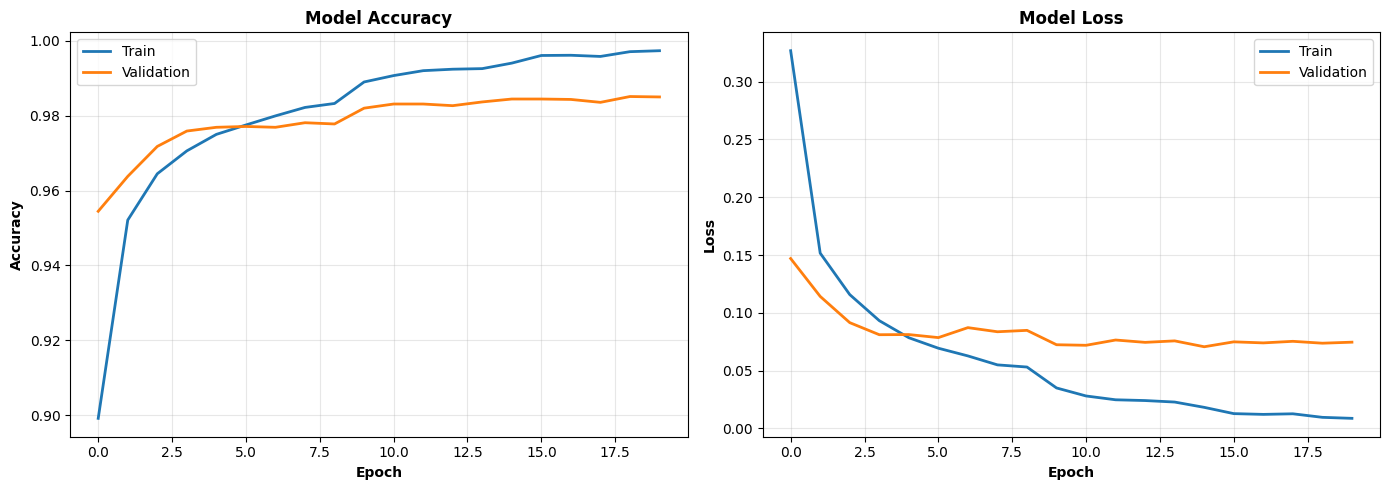

In [7]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Model Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Loss', fontweight='bold')
axes[1].set_title('Model Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

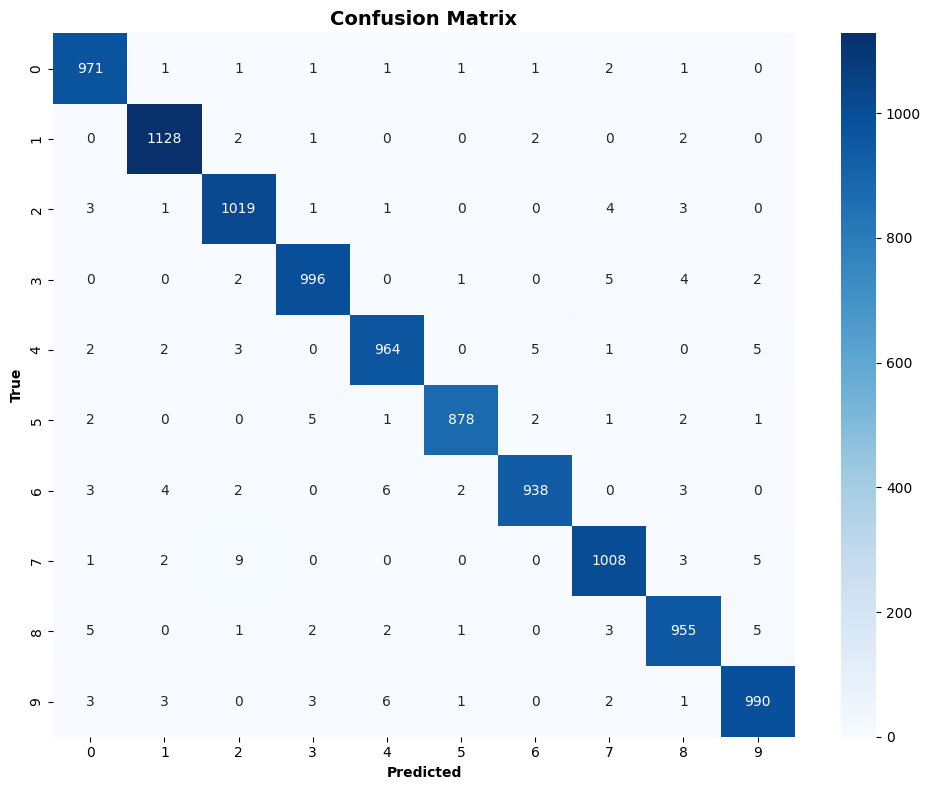

In [8]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('True', fontweight='bold')
plt.title('Confusion Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Model Persistence

In [9]:
# Sauvegarder le modele final
model.save('mlp_mnist_final.h5')
print('Model saved: mlp_mnist_final.h5')

# Sauvegarder les metriques
results = {
    'Model': 'MLP Baseline',
    'Architecture': '[512-256-128]',
    'Train_Accuracy': f"{history.history['accuracy'][-1]*100:.2f}%",
    'Val_Accuracy': f"{history.history['val_accuracy'][-1]*100:.2f}%",
    'Test_Accuracy': f"{test_accuracy*100:.2f}%",
    'Test_Loss': f"{test_loss:.4f}",
    'Parameters': model.count_params()
}

df_results = pd.DataFrame([results])
df_results.to_csv('mlp_results.csv', index=False)
print('Results saved: mlp_results.csv')
print('\n' + df_results.to_string(index=False))

Model saved: mlp_mnist_final.h5
Results saved: mlp_results.csv

       Model  Architecture Train_Accuracy Val_Accuracy Test_Accuracy Test_Loss  Parameters
MLP Baseline [512-256-128]         99.74%       98.50%        98.47%    0.0624      571018


---

## Conclusion

**Objectif** : Accuracy >95%  
**Resultat** : Consulter la metrique Test Accuracy ci-dessus

**Prochaine etape** : Phase 2 - CNN pour atteindre >99% accuracy